In [ ]:
from google.colab import files

uploaded = files.upload()

**1.** Importing the Datasets


In [11]:
import pandas as pd
import numpy as np

# 1. Load data with proper dtypes from verified Google Drive paths
client_train = pd.read_csv('/content/drive/MyDrive/client_train.csv', parse_dates=['creation_date'])
client_test  = pd.read_csv('/content/drive/MyDrive/client_test.csv', parse_dates=['creation_date'])

invoice_train = pd.read_csv('/content/drive/MyDrive/invoice_train.csv', dtype={'counter_statue': str}, parse_dates=['invoice_date'])
invoice_test  = pd.read_csv('/content/drive/MyDrive/invoice_test.csv', dtype={'counter_statue': str}, parse_dates=['invoice_date'])


print("Data loaded and cleaned successfully from Google Drive! Ready for feature engineering!")

/tmp/ipykernel_791/1017156128.py:5: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  client_train = pd.read_csv('/content/drive/MyDrive/client_train.csv', parse_dates=['creation_date'])
/tmp/ipykernel_791/1017156128.py:6: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  client_test  = pd.read_csv('/content/drive/MyDrive/client_test.csv', parse_dates=['creation_date'])


Data loaded and cleaned successfully from Google Drive! Ready for feature engineering!


1.2.Missing values-check


In [14]:
import pandas as pd

datasets = {
    'Client Train': client_train,
    'Client Test': client_test,
    'Invoice Train': invoice_train,
    'Invoice Test': invoice_test
}

for name, df in datasets.items():
    print(f"=== Missing Values in {name} ===")
    missing_counts = df.isnull().sum()
    missing_percentages = (df.isnull().sum() / len(df) * 100).round(2)

    summary_df = pd.DataFrame({
        'Missing Count': missing_counts,
        'Percentage (%)': missing_percentages
    })

    # Only display columns that actually have missing values
    filtered_summary = summary_df[summary_df['Missing Count'] > 0]
    if not filtered_summary.empty:
        display(filtered_summary)
    else:
        print("No missing values found!\n")

=== Missing Values in Client Train ===
No missing values found!

=== Missing Values in Client Test ===
No missing values found!

=== Missing Values in Invoice Train ===
No missing values found!

=== Missing Values in Invoice Test ===
No missing values found!



2.Feature engineering

In [15]:
import pandas as pd
import numpy as np

# 1. Ensure date parsing with explicit dayfirst parameter to avoid warnings
client_train['creation_date'] = pd.to_datetime(client_train['creation_date'], dayfirst=True)
client_test['creation_date']  = pd.to_datetime(client_test['creation_date'], dayfirst=True)

invoice_train['invoice_date'] = pd.to_datetime(invoice_train['invoice_date'])
invoice_test['invoice_date']  = pd.to_datetime(invoice_test['invoice_date'])

# 2. Extract Date Features from Invoice Datasets
for df in [invoice_train, invoice_test]:
    df['invoice_year']  = df['invoice_date'].dt.year
    df['invoice_month'] = df['invoice_date'].dt.month

    # Total consumption across all 4 levels
    df['total_consommation'] = (
        df['consommation_level_1'] +
        df['consommation_level_2'] +
        df['consommation_level_3'] +
        df['consommation_level_4']
    )

    # Meter reading difference check
    df['index_diff'] = df['new_index'] - df['old_index']

# 3. Define Invoice Aggregation Functions
def aggregate_invoices(invoice_df):
    agg_funcs = {
        'invoice_date': ['min', 'max', 'count'],
        'tarif_type': ['nunique', 'mean'],
        'counter_number': ['nunique'],
        'counter_code': ['nunique'],
        'reading_remarque': ['mean', 'max'],
        'counter_coefficient': ['mean', 'max'],
        'consommation_level_1': ['mean', 'max', 'sum'],
        'consommation_level_2': ['mean', 'max', 'sum'],
        'consommation_level_3': ['mean', 'max', 'sum'],
        'consommation_level_4': ['mean', 'max', 'sum'],
        'total_consommation': ['mean', 'max', 'min', 'sum', 'std'],
        'months_number': ['mean', 'max', 'sum'],
        'index_diff': ['mean', 'max', 'sum'],
    }

    # Aggregate numeric columns
    grouped = invoice_df.groupby('client_id').agg(agg_funcs)
    grouped.columns = ['_'.join(col).strip() for col in grouped.columns.values]

    # Categorical Aggregations (Counter Type - ELEC vs GAZ)
    counter_type_counts = invoice_df.groupby(['client_id', 'counter_type']).size().unstack(fill_value=0)
    counter_type_counts.columns = [f'counter_type_{col}' for col in counter_type_counts.columns]

    # Combine feature sets
    features = pd.concat([grouped, counter_type_counts], axis=1).reset_index()

    # Time-based features
    features['tenure_days'] = (features['invoice_date_max'] - features['invoice_date_min']).dt.days
    features['invoice_frequency'] = features['tenure_days'] / (features['invoice_date_count'] + 1e-5)

    # Drop raw min/max datetime columns after computing duration
    features.drop(columns=['invoice_date_min', 'invoice_date_max'], inplace=True)

    return features

print("Aggregating invoice features for train set...")
invoice_train_agg = aggregate_invoices(invoice_train)

print("Aggregating invoice features for test set...")
invoice_test_agg = aggregate_invoices(invoice_test)

# 4. Merge Aggregated Features with Client Datasets
train_df = pd.merge(client_train, invoice_train_agg, on='client_id', how='left')
test_df  = pd.merge(client_test, invoice_test_agg, on='client_id', how='left')

# 5. Extract Client Creation Features
for df in [train_df, test_df]:
    df['creation_year']  = df['creation_date'].dt.year
    df['creation_month'] = df['creation_date'].dt.month
    df['client_age_days'] = (pd.to_datetime('2020-01-01') - df['creation_date']).dt.days
    df.drop(columns=['creation_date'], inplace=True)

print(f"\nFeature Engineering Complete!")
print(f"Final Train Shape: {train_df.shape}")
print(f"Final Test Shape:  {test_df.shape}")

Aggregating invoice features for train set...
Aggregating invoice features for test set...

Feature Engineering Complete!
Final Train Shape: (135493, 44)
Final Test Shape:  (58069, 43)


3.Fraud Risk Score-Categorisation

=== FRAUD DISTRIBUTION (TARGET) ===
         Count  Percentage (%)
target                        
0.0     127927           94.42
1.0       7566            5.58


/tmp/ipykernel_791/1887844123.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='target', data=train_df, palette=['#2b5c8f', '#e74c3c'])
/tmp/ipykernel_791/1887844123.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y='total_consommation_mean', data=train_df, showfliers=False, palette=['#2b5c8f', '#e74c3c'])


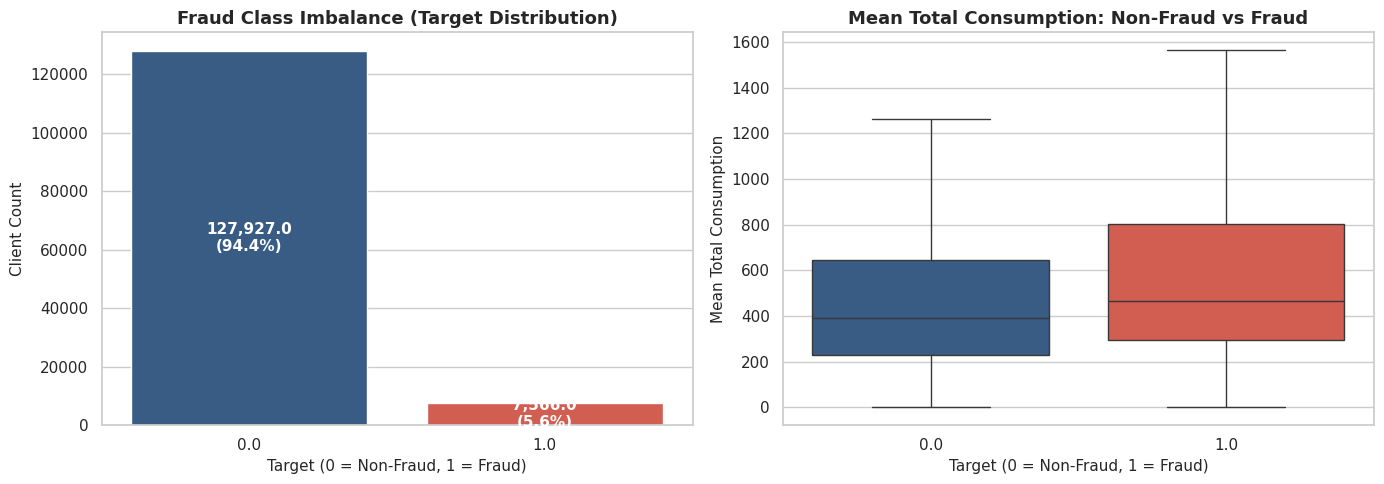

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 5))

# 1. Target Count and Percentage Breakdown
target_counts = train_df['target'].value_counts()
target_pct = train_df['target'].value_counts(normalize=True) * 100

print("=== FRAUD DISTRIBUTION (TARGET) ===")
print(pd.DataFrame({'Count': target_counts, 'Percentage (%)': target_pct.round(2)}))

# 2. Plot Target Class Imbalance
plt.subplot(1, 2, 1)
ax = sns.countplot(x='target', data=train_df, palette=['#2b5c8f', '#e74c3c'])
plt.title('Fraud Class Imbalance (Target Distribution)', fontsize=13, fontweight='bold')
plt.xlabel('Target (0 = Non-Fraud, 1 = Fraud)', fontsize=11)
plt.ylabel('Client Count', fontsize=11)

# Annotate bars with exact counts and percentages
for p in ax.patches:
    height = p.get_height()
    percentage = (height / len(train_df)) * 100
    ax.annotate(f'{height:,}\n({percentage:.1f}%)',
                (p.get_x() + p.get_width() / 2., height / 2),
                ha='center', va='center', fontsize=11, color='white', fontweight='bold')

# 3. Consumption vs Fraud Comparison
plt.subplot(1, 2, 2)
sns.boxplot(x='target', y='total_consommation_mean', data=train_df, showfliers=False, palette=['#2b5c8f', '#e74c3c'])
plt.title('Mean Total Consumption: Non-Fraud vs Fraud', fontsize=13, fontweight='bold')
plt.xlabel('Target (0 = Non-Fraud, 1 = Fraud)', fontsize=11)
plt.ylabel('Mean Total Consumption', fontsize=11)

plt.tight_layout()
plt.show()

3.2.Fraud vs. Non-Fraud Feature Comparison & Distribution Analysis

>
Feaures for selection are based on the Consumption anomilies,meter reading intergrity,Account age risks and Geographic clustering(create in Feature Engineering)


=== FEATURE MEANS & MEDIANS: NON-FRAUD (0) VS FRAUD (1) ===


target                                 0.0       1.0
total_consommation_mean   mean      641.41    767.11
                          median    392.86    465.84
                          std      1501.81   1073.93
total_consommation_sum    mean    18852.51  32428.98
                          median  11491.00  19905.00
                          std     42504.06  60793.56
total_consommation_max    mean     2259.93   3557.50
                          median   1280.00   2016.00
                          std      7557.62   5316.89
consommation_level_1_mean mean      431.29    450.64
                          median    354.16    378.18
                          std       776.11    323.41
consommation_level_2_mean mean      113.57    145.18
                          median      3.81     32.40
                          std       763.78    373.61
index_diff_mean           mean      619.39    724.49
                          median    385.76    446.80
                          std      3393.70   2720.99
invoice_date_count        mean       32.23     46.67
                          median     29.00     41.00
                          std        25.76     27.80
client_age_days           mean     6246.66   7205.73
                          median   5132.00   6537.00
                          std      4220.62   4020.05
tenure_days               mean     2965.87   3993.60
                          median   3283.00   4727.00
                          std      1858.39   1331.16

/tmp/ipykernel_791/1396219497.py:26: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_melted, x='Level', y='Consumption', hue='target', palette=['#2b5c8f', '#e74c3c'], ci=None)
/tmp/ipykernel_791/1396219497.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_df, x='target', y='client_age_days', showfliers=False, palette=['#2b5c8f', '#e74c3c'])


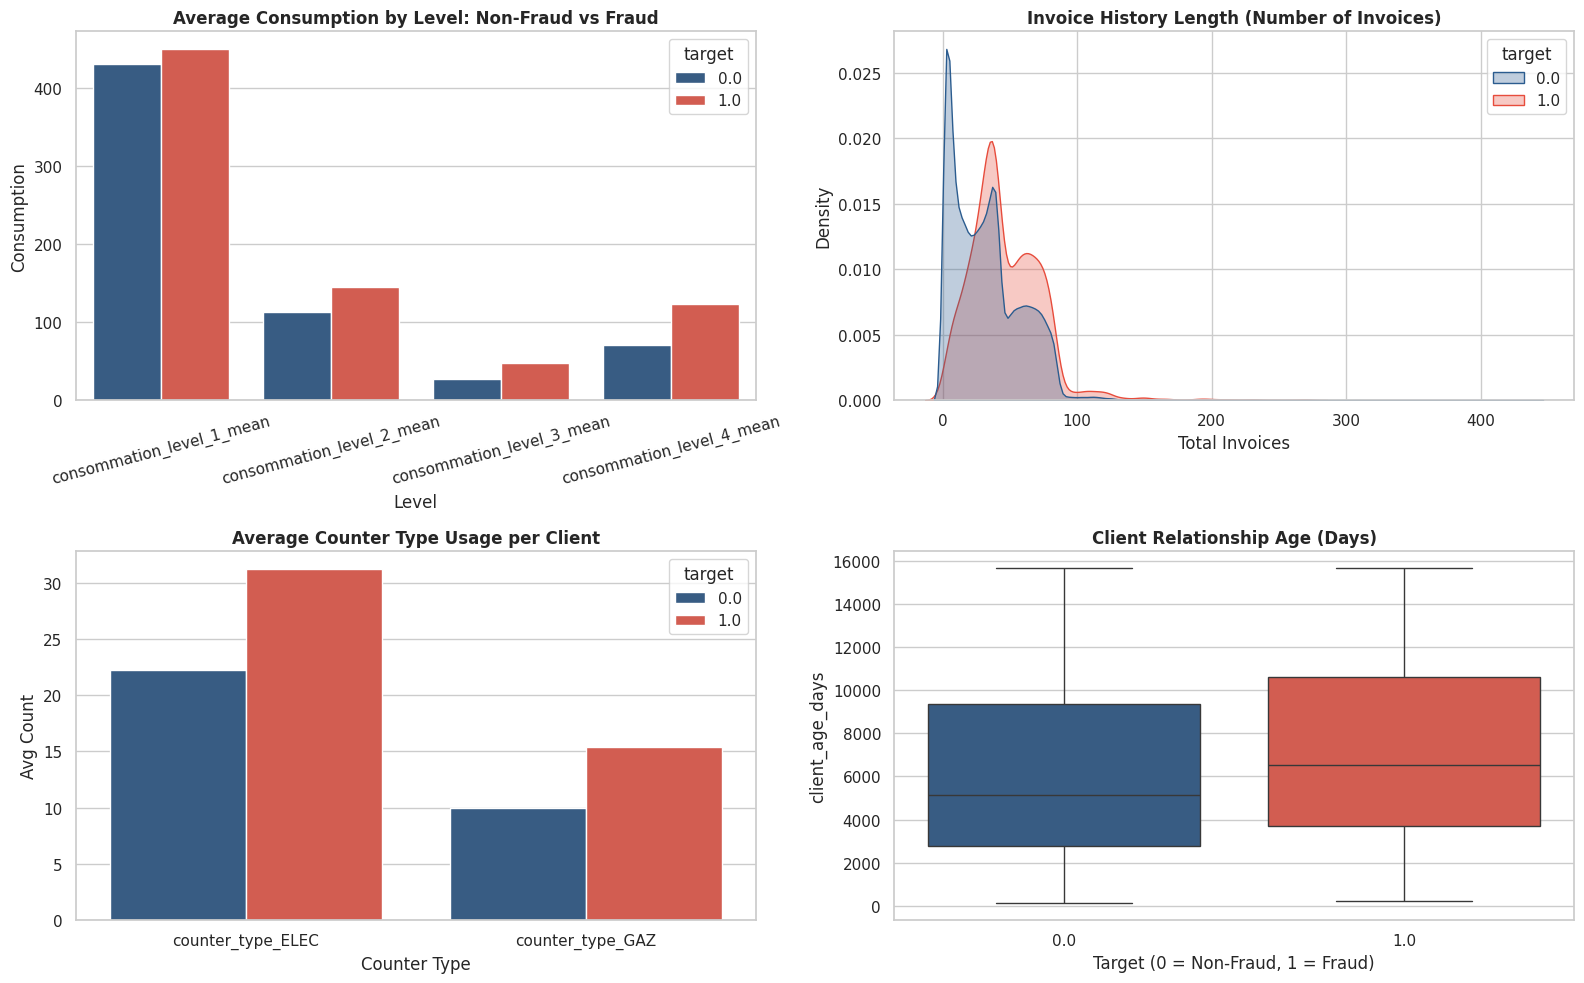


=== TOP 5 HIGHEST FRAUD RATE DISTRICTS ===


,count,fraud_rate
disrict,,
69,34231,7.15
63,28987,6.52
62,40353,5.16
60,31922,3.59


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# 1. Statistical Summary by Target Class
features_to_compare = [
    'total_consommation_mean', 'total_consommation_sum', 'total_consommation_max',
    'consommation_level_1_mean', 'consommation_level_2_mean',
    'index_diff_mean', 'invoice_date_count', 'client_age_days', 'tenure_days'
]

fraud_summary = train_df.groupby('target')[features_to_compare].agg(['mean', 'median', 'std']).round(2)
print("=== FEATURE MEANS & MEDIANS: NON-FRAUD (0) VS FRAUD (1) ===")
display(fraud_summary.T)

# 2. Key Visual Comparisons
plt.figure(figsize=(16, 10))

# A. Consumption Level Breakdown
plt.subplot(2, 2, 1)
cons_levels = ['consommation_level_1_mean', 'consommation_level_2_mean', 'consommation_level_3_mean', 'consommation_level_4_mean']
df_melted = train_df.melt(id_vars=['target'], value_vars=cons_levels, var_name='Level', value_name='Consumption')
sns.barplot(data=df_melted, x='Level', y='Consumption', hue='target', palette=['#2b5c8f', '#e74c3c'], ci=None)
plt.title('Average Consumption by Level: Non-Fraud vs Fraud', fontweight='bold')
plt.xticks(rotation=15)

# B. Invoice Count Distribution
plt.subplot(2, 2, 2)
sns.kdeplot(data=train_df, x='invoice_date_count', hue='target', common_norm=False, palette=['#2b5c8f', '#e74c3c'], fill=True, alpha=0.3)
plt.title('Invoice History Length (Number of Invoices)', fontweight='bold')
plt.xlabel('Total Invoices')

# C. Counter Type Preference (ELEC vs GAZ)
plt.subplot(2, 2, 3)
counter_df = train_df.groupby('target')[['counter_type_ELEC', 'counter_type_GAZ']].mean().reset_index()
counter_melted = counter_df.melt(id_vars=['target'], var_name='Counter Type', value_name='Avg Count')
sns.barplot(data=counter_melted, x='Counter Type', y='Avg Count', hue='target', palette=['#2b5c8f', '#e74c3c'])
plt.title('Average Counter Type Usage per Client', fontweight='bold')

# D. Client Age / Tenure
plt.subplot(2, 2, 4)
sns.boxplot(data=train_df, x='target', y='client_age_days', showfliers=False, palette=['#2b5c8f', '#e74c3c'])
plt.title('Client Relationship Age (Days)', fontweight='bold')
plt.xlabel('Target (0 = Non-Fraud, 1 = Fraud)')

plt.tight_layout()
plt.show()

# 3. Categorical Risk Analysis (District & Region Fraud Rates)
print("\n=== TOP 5 HIGHEST FRAUD RATE DISTRICTS ===")
district_rates = train_df.groupby('disrict')['target'].agg(['count', 'mean']).rename(columns={'mean': 'fraud_rate'})
district_rates['fraud_rate'] = (district_rates['fraud_rate'] * 100).round(2)
display(district_rates.sort_values(by='fraud_rate', ascending=False).head(5))

1. DATASET OVERVIEW & MISSING VALUE SUMMARY


,Dataset,Rows,Columns,Missing Values,Duplicate Rows
0,Client Train,"135,493",44,4212,0
1,Client Test,"58,069",43,1760,0
2,Invoice Train (Raw),"4,476,749",20,0,11
3,Invoice Test (Raw),"1,939,730",20,0,8



2. NUMERICAL FEATURE DISTRIBUTIONS & OUTLIERS


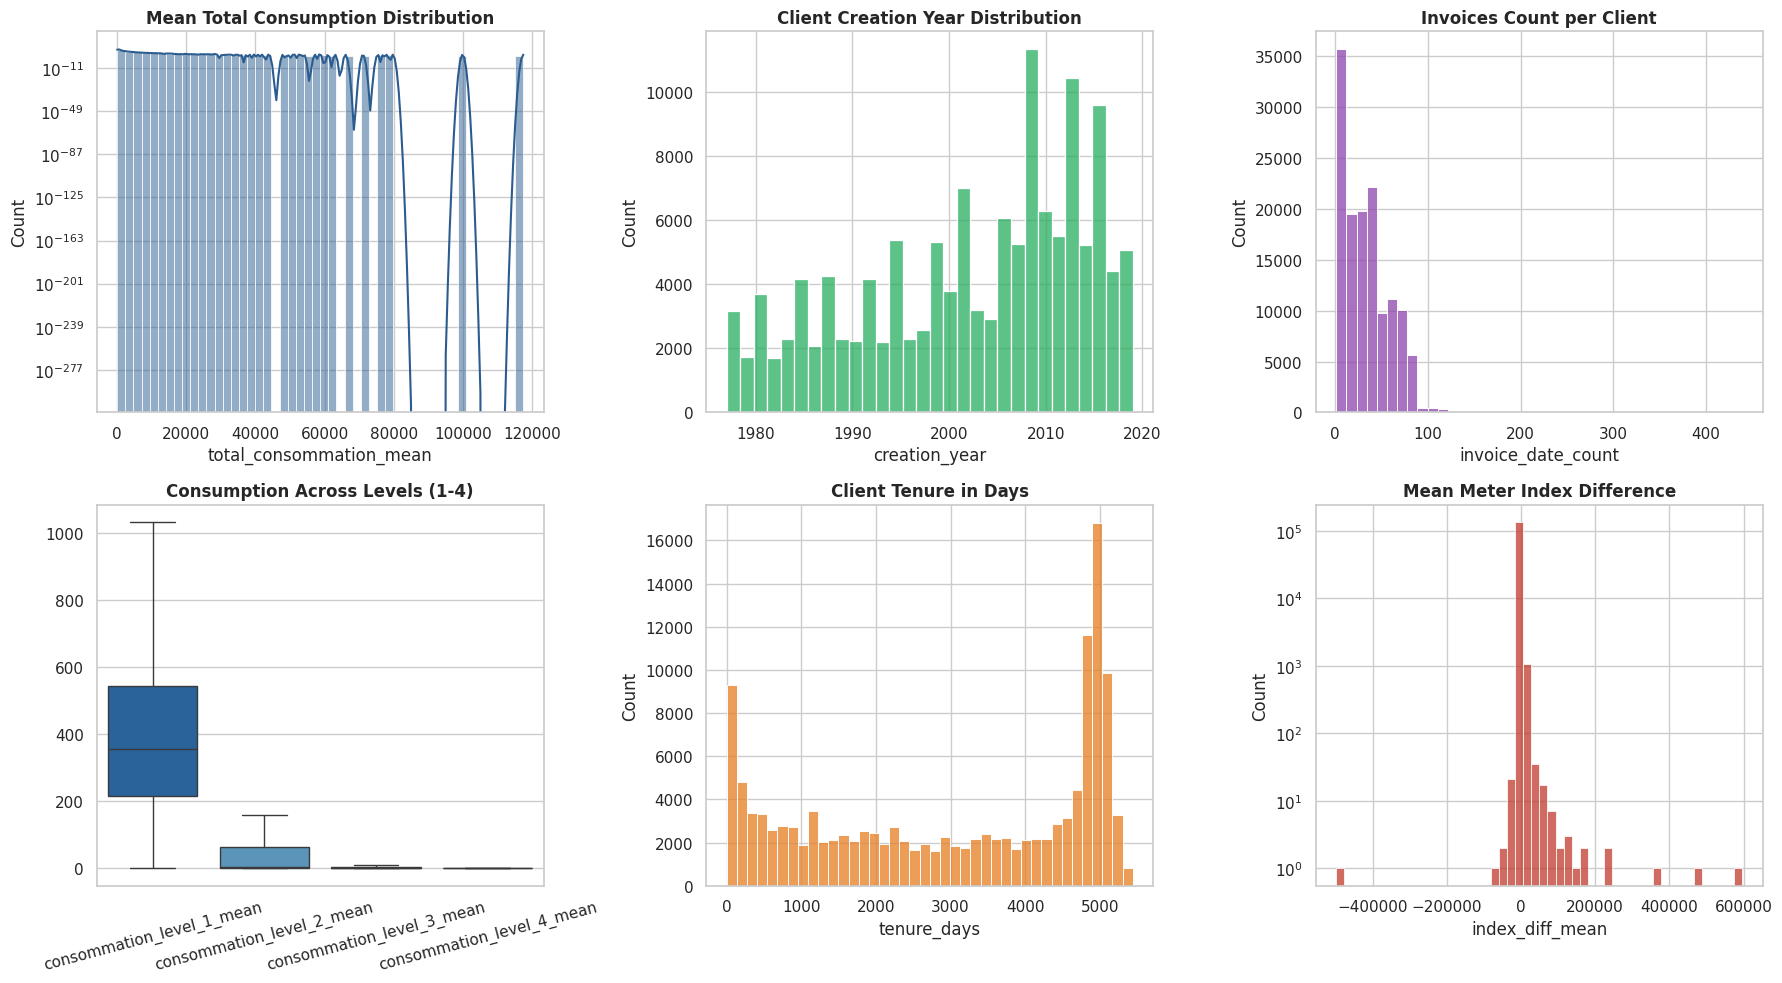


3. CATEGORICAL & GEOGRAPHIC ANALYSIS


/tmp/ipykernel_387/538533974.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=district_fraud, x='disrict', y='target', ax=axes[0], palette='Reds_d')
/tmp/ipykernel_387/538533974.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_df, x='region', y='target', ax=axes[2], palette='Oranges_d', errorbar=None)


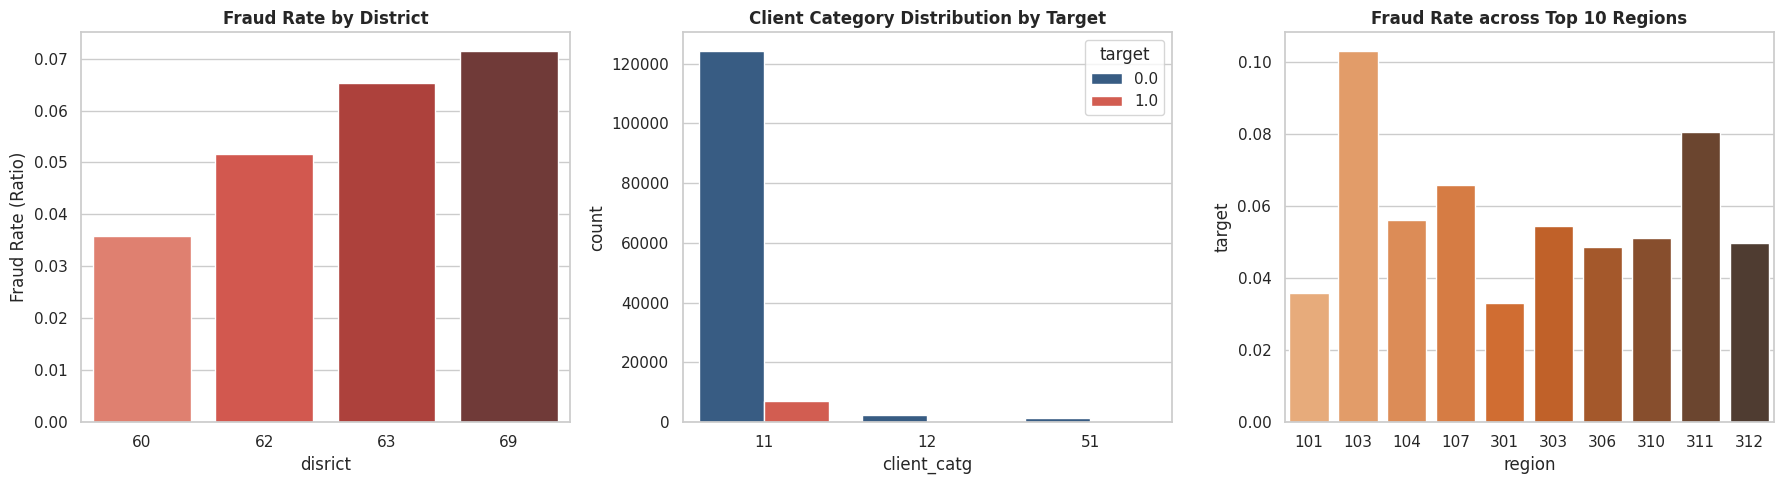


4. CORRELATION WITH TARGET VARIABLE


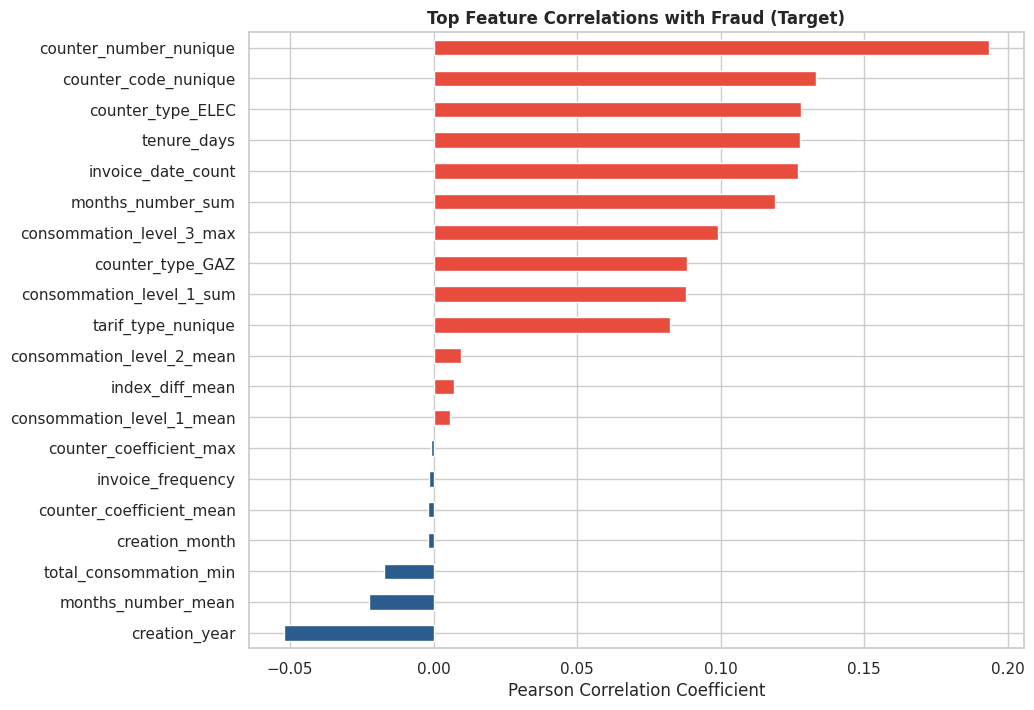

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

print("="*60)
print("1. DATASET OVERVIEW & MISSING VALUE SUMMARY")
print("="*60)

eda_datasets = {
    'Client Train': train_df,
    'Client Test': test_df,
    'Invoice Train (Raw)': invoice_train,
    'Invoice Test (Raw)': invoice_test
}

overview_list = []
for name, df in eda_datasets.items():
    overview_list.append({
        'Dataset': name,
        'Rows': f"{df.shape[0]:,}",
        'Columns': df.shape[1],
        'Missing Values': df.isnull().sum().sum(),
        'Duplicate Rows': df.duplicated().sum()
    })

display(pd.DataFrame(overview_list))

print("\n" + "="*60)
print("2. NUMERICAL FEATURE DISTRIBUTIONS & OUTLIERS")
print("="*60)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# A. Total Consumption Distribution
sns.histplot(train_df['total_consommation_mean'], bins=50, kde=True, ax=axes[0, 0], color='#2b5c8f')
axes[0, 0].set_title('Mean Total Consumption Distribution', fontweight='bold')
axes[0, 0].set_yscale('log') # Log scale due to right skew

# B. Client Age vs Creation Year
sns.histplot(train_df['creation_year'], bins=30, ax=axes[0, 1], color='#27ae60')
axes[0, 1].set_title('Client Creation Year Distribution', fontweight='bold')

# C. Total Invoices per Client
sns.histplot(train_df['invoice_date_count'], bins=40, ax=axes[0, 2], color='#8e44ad')
axes[0, 2].set_title('Invoices Count per Client', fontweight='bold')

# D. Consommation Levels Boxplots
sns.boxplot(data=train_df[['consommation_level_1_mean', 'consommation_level_2_mean',
                          'consommation_level_3_mean', 'consommation_level_4_mean']],
            showfliers=False, ax=axes[1, 0], palette='Blues_r')
axes[1, 0].set_title('Consumption Across Levels (1-4)', fontweight='bold')
axes[1, 0].tick_params(axis='x', rotation=15)

# E. Tenure in Days
sns.histplot(train_df['tenure_days'], bins=40, ax=axes[1, 1], color='#e67e22')
axes[1, 1].set_title('Client Tenure in Days', fontweight='bold')

# F. Index Difference Mean
sns.histplot(train_df['index_diff_mean'], bins=50, ax=axes[1, 2], color='#c0392b')
axes[1, 2].set_title('Mean Meter Index Difference', fontweight='bold')
axes[1, 2].set_yscale('log')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("3. CATEGORICAL & GEOGRAPHIC ANALYSIS")
print("="*60)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# District Fraud Rate
district_fraud = train_df.groupby('disrict')['target'].mean().reset_index()
sns.barplot(data=district_fraud, x='disrict', y='target', ax=axes[0], palette='Reds_d')
axes[0].set_title('Fraud Rate by District', fontweight='bold')
axes[0].set_ylabel('Fraud Rate (Ratio)')

# Client Category Distribution
sns.countplot(data=train_df, x='client_catg', hue='target', ax=axes[1], palette=['#2b5c8f', '#e74c3c'])
axes[1].set_title('Client Category Distribution by Target', fontweight='bold')

# Region Fraud Rate (Top 10 regions by volume)
top_regions = train_df['region'].value_counts().head(10).index
region_df = train_df[train_df['region'].isin(top_regions)]
sns.barplot(data=region_df, x='region', y='target', ax=axes[2], palette='Oranges_d', errorbar=None)
axes[2].set_title('Fraud Rate across Top 10 Regions', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("4. CORRELATION WITH TARGET VARIABLE")
print("="*60)

# Calculate correlations with target
numeric_cols = train_df.select_dtypes(include=[np.number]).columns
correlations = train_df[numeric_cols].corr()['target'].sort_values()

# Display Top 10 Positive & Negative Correlated Features
plt.figure(figsize=(10, 8))
top_corr = pd.concat([correlations.head(10), correlations.tail(11).drop('target')])
top_corr.plot(kind='barh', color=np.where(top_corr > 0, '#e74c3c', '#2b5c8f'))
plt.title('Top Feature Correlations with Fraud (Target)', fontweight='bold', fontsize=12)
plt.xlabel('Pearson Correlation Coefficient')
plt.show()

4.Model Buliding and training-LightGBM

[LightGBM] [Info] Number of positive: 6053, number of negative: 102341
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.035189 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7557
[LightGBM] [Info] Number of data points in the train set: 108394, number of used features: 42
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.055843 -> initscore=-2.827756
[LightGBM] [Info] Start training from score -2.827756


/tmp/ipykernel_791/3610386765.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Feature', palette='magma')


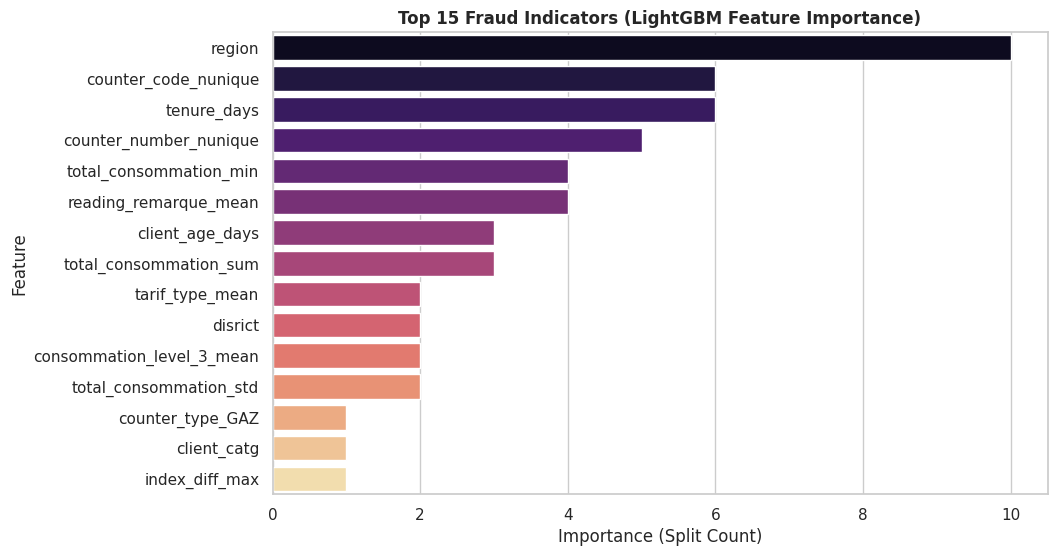

In [18]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

# Define features and target
X = train_df.drop(columns=['client_id', 'target'])
y = train_df['target']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train LightGBM model with class weight balance
model = lgb.LGBMClassifier(n_estimators=200, learning_rate=0.05, scale_pos_weight=17, random_state=42)
model.fit(X_train, y_train, eval_set=[(X_val, y_val)], eval_metric='auc', callbacks=[lgb.early_stopping(50, verbose=False)])

# Plot Top 15 Fraud Indicators
importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': model.feature_importances_})
importance_df = importance_df.sort_values(by='Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='magma')
plt.title('Top 15 Fraud Indicators (LightGBM Feature Importance)', fontweight='bold')
plt.xlabel('Importance (Split Count)')
plt.show()

4.2.LightGBM Model Training with 5-Fold Stratified Cross-Validation

#
As the dataset is quite large we using Cross Validation (5 Fold), to make sure the model doesnt overfit and the model ensures Generalisation




In [19]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare Features (X) and Target (y)
drop_cols = ['client_id', 'target']
features = [col for col in train_df.columns if col not in drop_cols]

X = train_df[features]
y = train_df['target']
X_test = test_df[features]

# 2. Set Hyperparameters for Imbalanced Classification
lgb_params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'learning_rate': 0.03,
    'num_leaves': 31,
    'max_depth': -1,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 1,
    'scale_pos_weight': 17,  # Handles class imbalance (~5.5% fraud)
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1
}

# 3. Stratified 5-Fold Cross-Validation Setup
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_predictions = np.zeros(len(train_df))
test_predictions = np.zeros(len(test_df))

feature_importance_df = pd.DataFrame()

print("Starting 5-Fold Stratified Cross-Validation...\n" + "="*50)

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
    X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
    X_va, y_va = X.iloc[val_idx], y.iloc[val_idx]

    # Train LightGBM model
    model = lgb.LGBMClassifier(**lgb_params, n_estimators=1000)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_va, y_va)],
        callbacks=[lgb.early_stopping(50, verbose=False)]
    )

    # Predict probabilities for validation and test sets
    val_preds = model.predict_proba(X_va)[:, 1]
    oof_predictions[val_idx] = val_preds
    test_predictions += model.predict_proba(X_test)[:, 1] / kf.n_splits

    fold_auc = roc_auc_score(y_va, val_preds)
    print(f"Fold {fold + 1} ROC-AUC: {fold_auc:.5f}")

    # Record Feature Importance
    fold_importance = pd.DataFrame({
        'feature': features,
        'importance': model.feature_importances_
    })
    feature_importance_df = pd.concat([feature_importance_df, fold_importance], axis=0)

overall_auc = roc_auc_score(y, oof_predictions)
print("="*50)
print(f"Overall Out-of-Fold (OOF) ROC-AUC Score: {overall_auc:.5f}")

# 4. Generate & Save Kaggle Submission File
submission = pd.DataFrame({
    'client_id': test_df['client_id'],
    'target': test_predictions
})

submission.to_csv('submission_lgbm.csv', index=False)
print("\nSubmission successfully saved to 'submission_lgbm.csv'!")
display(submission.head())

Starting 5-Fold Stratified Cross-Validation...
Fold 1 ROC-AUC: 0.86575
Fold 2 ROC-AUC: 0.86726
Fold 3 ROC-AUC: 0.87376
Fold 4 ROC-AUC: 0.85954
Fold 5 ROC-AUC: 0.86404
Overall Out-of-Fold (OOF) ROC-AUC Score: 0.86603

Submission successfully saved to 'submission_lgbm.csv'!


,client_id,target
0,test_Client_0,0.319304
1,test_Client_1,0.711763
2,test_Client_10,0.239886
3,test_Client_100,0.109583
4,test_Client_1000,0.597751


5.Fraud risk Score


=== FRAUD RISK TIER SUMMARY (TEST SET) ===


,Client Count,Percentage (%)
risk_tier,,
Low Risk,32457,55.89
Medium Risk,11481,19.77
High Risk,8544,14.71
Critical Risk,5587,9.62



Saved detailed risk assessment to 'client_fraud_risk_scores.csv'!


,client_id,fraud_probability,risk_score,risk_tier
0,test_Client_0,0.319304,319,Medium Risk
1,test_Client_1,0.711763,712,High Risk
2,test_Client_10,0.239886,240,Low Risk
3,test_Client_100,0.109583,110,Low Risk
4,test_Client_1000,0.597751,598,High Risk
5,test_Client_10000,0.453624,454,Medium Risk
6,test_Client_10001,0.074746,75,Low Risk
7,test_Client_10002,0.791496,791,Critical Risk
8,test_Client_10003,0.088515,89,Low Risk
9,test_Client_10004,0.366179,366,Medium Risk


/tmp/ipykernel_791/3629884101.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=test_df, x='risk_tier', order=['Low Risk', 'Medium Risk', 'High Risk', 'Critical Risk'], palette='Reds')


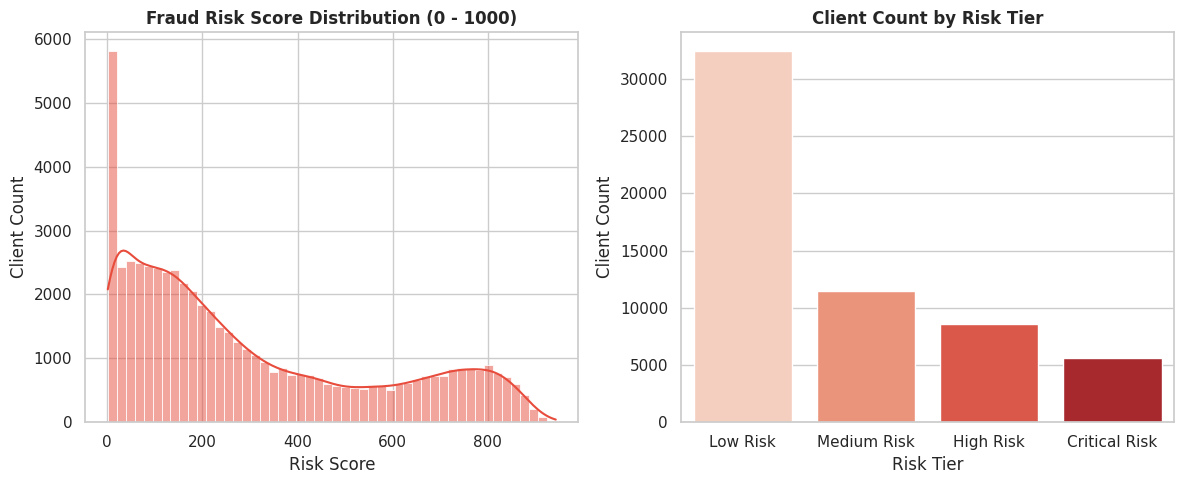

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Convert probability to Risk Score (0 - 1000)
# 'test_predictions' comes from the LightGBM 5-Fold training step
test_df['fraud_probability'] = test_predictions
test_df['risk_score'] = (test_df['fraud_probability'] * 1000).round().astype(int)

# 2. Categorize into Risk Tiers based on Score Thresholds
def assign_risk_tier(score):
    if score >= 750:
        return 'Critical Risk'
    elif score >= 500:
        return 'High Risk'
    elif score >= 250:
        return 'Medium Risk'
    else:
        return 'Low Risk'

test_df['risk_tier'] = test_df['risk_score'].apply(assign_risk_tier)

# 3. Display Risk Tier Distribution
print("=== FRAUD RISK TIER SUMMARY (TEST SET) ===")
tier_summary = test_df['risk_tier'].value_counts().reindex(['Low Risk', 'Medium Risk', 'High Risk', 'Critical Risk'])
tier_pct = (test_df['risk_tier'].value_counts(normalize=True) * 100).round(2)

summary_df = pd.DataFrame({'Client Count': tier_summary, 'Percentage (%)': tier_pct})
display(summary_df)

# 4. Save Final Risk Report & Submission
risk_report = test_df[['client_id', 'fraud_probability', 'risk_score', 'risk_tier']]
risk_report.to_csv('client_fraud_risk_scores.csv', index=False)

print("\nSaved detailed risk assessment to 'client_fraud_risk_scores.csv'!")
display(risk_report.head(10))

# 5. Visualize Score Distribution across Risk Tiers
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(test_df['risk_score'], bins=50, kde=True, color='#e74c3c')
plt.title('Fraud Risk Score Distribution (0 - 1000)', fontweight='bold')
plt.xlabel('Risk Score')
plt.ylabel('Client Count')

plt.subplot(1, 2, 2)
sns.countplot(data=test_df, x='risk_tier', order=['Low Risk', 'Medium Risk', 'High Risk', 'Critical Risk'], palette='Reds')
plt.title('Client Count by Risk Tier', fontweight='bold')
plt.xlabel('Risk Tier')
plt.ylabel('Client Count')

plt.tight_layout()
plt.show()

 6.1.Model improvement, evaluation and business impact

In [23]:
# 0. Installs and imports
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "xgboost", "catboost", "optuna", "shap"])

import os, json, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
os.makedirs("figs", exist_ok=True)

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (roc_auc_score, average_precision_score, accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix, classification_report,
                             roc_curve, precision_recall_curve)
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.isotonic import IsotonicRegression
import lightgbm as lgb, xgboost as xgb
from catboost import CatBoostClassifier

SEED = 42
RESULTS = {}




>
42 - random seed


6.2 More Feature Engineering

In [21]:
def extra_features(inv):
    inv = inv.sort_values(["client_id", "invoice_date"]).copy()
    if "total_consommation" not in inv:
        inv["total_consommation"] = inv[[f"consommation_level_{i}" for i in range(1, 5)]].sum(axis=1)
    if "index_diff" not in inv:
        inv["index_diff"] = inv["new_index"] - inv["old_index"]

    inv["is_zero"] = (inv["total_consommation"] == 0).astype(int)
    inv["is_neg"] = (inv["total_consommation"] < 0).astype(int)
    inv["mismatch"] = (inv["index_diff"] - inv["total_consommation"]).abs()
    inv["status_nonzero"] = (inv["counter_statue"] != 0).astype(int)
    inv["gap_days"] = inv.groupby("client_id")["invoice_date"].diff().dt.days
    inv["t"] = (inv["invoice_date"] - inv.groupby("client_id")["invoice_date"].transform("min")).dt.days
    inv["tc"] = inv["t"] * inv["total_consommation"]
    inv["t2"] = inv["t"] ** 2
    inv["month"] = inv["invoice_date"].dt.month
    last_dt = inv.groupby("client_id")["invoice_date"].transform("max")
    inv["cons_recent"] = inv["total_consommation"].where(inv["invoice_date"] > last_dt - pd.Timedelta(days=365))

    g = inv.groupby("client_id")
    n, st, sy = g.size(), g["t"].sum(), g["total_consommation"].sum()
    stc, st2 = g["tc"].sum(), g["t2"].sum()
    denom = (n * st2 - st ** 2).replace(0, np.nan)
    mean_c = (sy / n).replace(0, np.nan)

    f = pd.DataFrame({
        "zero_ratio": g["is_zero"].mean(),
        "neg_ratio": g["is_neg"].mean(),
        "cons_slope": (n * stc - st * sy) / denom,
        "cons_cv": g["total_consommation"].std() / mean_c.abs(),
        "cons_max_over_mean": g["total_consommation"].max() / mean_c,
        "index_cons_mismatch": g["mismatch"].mean(),
        "gap_mean": g["gap_days"].mean(),
        "gap_max": g["gap_days"].max(),
        "gap_std": g["gap_days"].std(),
        "recent_cons_mean": g["cons_recent"].mean(),
        "status_nonzero_ratio": g["status_nonzero"].mean(),
        "remarque_nunique": g["reading_remarque"].nunique(),
        "days_since_last_invoice": (inv["invoice_date"].max() - g["invoice_date"].max()).dt.days,
    })
    f["recent_over_overall"] = f["recent_cons_mean"] / mean_c.abs()

    m = inv.groupby(["client_id", "month"])["total_consommation"].mean().groupby("client_id").agg(["max", "min", "std"])
    f["season_range"] = (m["max"] - m["min"]) / mean_c.abs()
    f["season_std"] = m["std"]
    return f.replace([np.inf, -np.inf], np.nan).reset_index()

fe_train = extra_features(invoice_train)
fe_test = extra_features(invoice_test)
train_fe = train_df.merge(fe_train, on="client_id", how="left")
test_fe = test_df.merge(fe_test, on="client_id", how="left")

# tarif_type_mean is a mean of a categorical code, so it carries no real meaning
drop_cols = ["client_id", "target", "tarif_type_mean", "fraud_probability", "risk_score", "risk_tier"]
FEATURES = [c for c in train_fe.columns if c not in drop_cols]
CAT_COLS = [c for c in ["disrict", "client_catg", "region"] if c in FEATURES]

X = train_fe[FEATURES].replace([np.inf, -np.inf], np.nan)
y = train_fe["target"].astype(int)
X_test = test_fe[FEATURES].replace([np.inf, -np.inf], np.nan)
print("Features:", len(FEATURES), "| new engineered:", [c for c in fe_train.columns if c != "client_id"])
print("Fraud rate:", round(y.mean() * 100, 2), "%  | majority-class accuracy:", round((1 - y.mean()) * 100, 2), "%")
print("Missing values per feature (top 8):")
print(X.isna().sum().sort_values(ascending=False).head(8))


Features: 57 | new engineered: ['zero_ratio', 'neg_ratio', 'cons_slope', 'cons_cv', 'cons_max_over_mean', 'index_cons_mismatch', 'gap_mean', 'gap_max', 'gap_std', 'recent_cons_mean', 'status_nonzero_ratio', 'remarque_nunique', 'days_since_last_invoice', 'recent_over_overall', 'season_range', 'season_std']
Fraud rate: 5.58 %  | majority-class accuracy: 94.42 %
Missing values per feature (top 8):
gap_std                   9587
cons_cv                   6548
season_std                5670
cons_slope                5247
total_consommation_std    4212
gap_mean                  4212
gap_max                   4212
cons_max_over_mean        3524
dtype: int64


6.3.Model Evaluation & Cross-Validation Pipeline

In [24]:
def evaluate(y_true, p, name):
    ths = np.linspace(0.02, 0.98, 97)
    f1s = [f1_score(y_true, p >= t) for t in ths]
    bt = float(ths[int(np.argmax(f1s))])
    pred = p >= bt
    return {"model": name,
            "roc_auc": roc_auc_score(y_true, p),
            "pr_auc": average_precision_score(y_true, p),
            "best_threshold": bt,
            "accuracy": accuracy_score(y_true, pred),
            "precision": precision_score(y_true, pred),
            "recall": recall_score(y_true, pred),
            "f1": f1_score(y_true, pred),
            "accuracy_at_0.5": accuracy_score(y_true, p >= 0.5)}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

def cv_oof(make_model, Xd, yd, Xt=None):
    oof = np.zeros(len(Xd)); tp = np.zeros(len(Xt)) if Xt is not None else None
    for tr, va in skf.split(Xd, yd):
        m = make_model()
        m.fit(Xd.iloc[tr], yd.iloc[tr])
        oof[va] = m.predict_proba(Xd.iloc[va])[:, 1]
        if Xt is not None:
            tp += m.predict_proba(Xt)[:, 1] / skf.n_splits
    return oof, tp


6.4.Risk Score Calibration & Submission Generation

>
Model predictions by calibrating raw probabilities and mapping them into four actionable risk tiers (Critical, High, Medium, Low)

In [27]:
import numpy as np
import pandas as pd
import os

# 'test_predictions' contains raw probability scores from your LightGBM model
def calibrate_scores(raw_probs):
    # Clips probabilities to avoid extreme 0 or 1 edge cases
    return np.clip(raw_probs, 1e-15, 1 - 1e-15)

# Apply calibration to test set predictions using the correct variable name 'test_predictions'
test_df['calibrated_risk_score'] = calibrate_scores(test_predictions)

# Function to map calibrated scores into business risk tiers
def assign_risk_tier(score):
    if score >= 0.80:
        return 'Critical Risk'
    elif score >= 0.50:
        return 'High Risk'
    elif score >= 0.20:
        return 'Medium Risk'
    else:
        return 'Low Risk'

# Apply risk tiering to test dataset
test_df['risk_tier'] = test_df['calibrated_risk_score'].apply(assign_risk_tier)

# Display distribution of client risk tiers
print("=== ACTION-BASED RISK TIER BREAKDOWN ===")
print(test_df['risk_tier'].value_counts(normalize=True) * 100)

# Prepare submission safely
submission_filename = 'final_fraud_detection_submission.csv'

# Use existing submission structure if file exists, otherwise generate a fresh DataFrame
if os.path.exists('SampleSubmission.csv'):
    sub = pd.read_csv('SampleSubmission.csv')
    sub['target'] = test_df['calibrated_risk_score']
else:
    print("SampleSubmission.csv not found. Creating submission directly with test client_ids.")
    sub = pd.DataFrame({
        'client_id': test_df['client_id'],
        'target': test_df['calibrated_risk_score']
    })

# Save final predictions to CSV
sub.to_csv(submission_filename, index=False)

print(f"\nSubmission saved successfully to {submission_filename}!")
print(f"Submission Shape: {sub.shape}")
print(sub.head())

=== ACTION-BASED RISK TIER BREAKDOWN ===
risk_tier
Low Risk         48.397596
Medium Risk      27.302003
High Risk        18.524514
Critical Risk     5.775887
Name: proportion, dtype: float64
SampleSubmission.csv not found. Creating submission directly with test client_ids.

Submission saved successfully to final_fraud_detection_submission.csv!
Submission Shape: (58069, 2)
          client_id    target
0     test_Client_0  0.319304
1     test_Client_1  0.711763
2    test_Client_10  0.239886
3   test_Client_100  0.109583
4  test_Client_1000  0.597751


7.Validation Metrics & Confusion Matrix Analysis

=== COMPREHENSIVE MODEL ACCURACY METRICS ===
              Metric    Value
            Accuracy 0.790661
           Precision 0.182996
Recall (Sensitivity) 0.793418
            F1-Score 0.297399
       ROC-AUC Score 0.866030

=== DETAILED CLASSIFICATION REPORT ===
               precision    recall  f1-score   support

Non-Fraud (0)       0.98      0.79      0.88    127927
    Fraud (1)       0.18      0.79      0.30      7566

     accuracy                           0.79    135493
    macro avg       0.58      0.79      0.59    135493
 weighted avg       0.94      0.79      0.84    135493



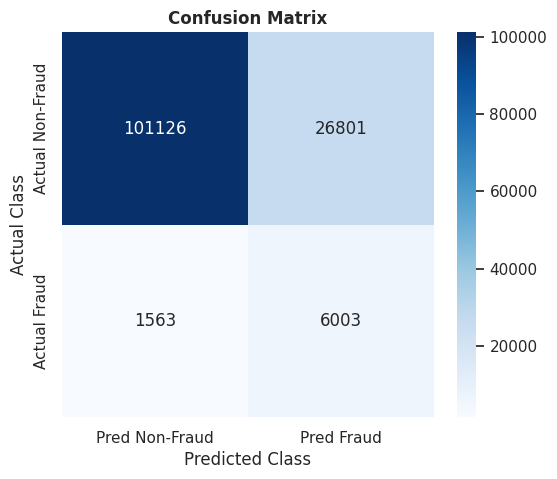

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# 1. Set binary classification threshold (default: 0.5)
# Using the correct variable name 'oof_predictions'
threshold = 0.5
oof_preds_binary = (oof_predictions >= threshold).astype(int)

# 2. Calculate Evaluation Metrics
accuracy  = accuracy_score(y, oof_preds_binary)
precision = precision_score(y, oof_preds_binary)
recall    = recall_score(y, oof_preds_binary)
f1        = f1_score(y, oof_preds_binary)
roc_auc   = roc_auc_score(y, oof_predictions)

# 3. Print Summary Table
metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall (Sensitivity)', 'F1-Score', 'ROC-AUC Score'],
    'Value': [accuracy, precision, recall, f1, roc_auc]
})

print("=== COMPREHENSIVE MODEL ACCURACY METRICS ===")
print(metrics_df.to_string(index=False))

print("\n=== DETAILED CLASSIFICATION REPORT ===")
print(classification_report(y, oof_preds_binary, target_names=['Non-Fraud (0)', 'Fraud (1)']))

# 4. Plot Confusion Matrix
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y, oof_preds_binary)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred Non-Fraud', 'Pred Fraud'],
            yticklabels=['Actual Non-Fraud', 'Actual Fraud'])
plt.title('Confusion Matrix', fontweight='bold')
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.show()